# How to run `quflow` on a cluster

Here, we use the cluster Vera available via [C3SE](https://www.c3se.chalmers.se/). The setup can be adapted to other settings.

In [1]:
# For non-interactive plots:
%matplotlib inline

# Looks better on macbooks
%config InlineBackend.figure_format = 'retina' 

# Modules to load
import numpy as np
import matplotlib.pyplot as plt
import quflow as qf
from quflow.constraints import *

# Matplotlib style
# plt.style.use('dark_background')
# plt.style.use('default')

### Parameters

In [2]:
N = 64

filename = "mysim_N_{}.hdf5".format(N)
prerun_code = ""
# Constraint method: "lu" (sparse, fast) or "svd" (dense, well-conditioned)
constraint_method = "qr"
solver_method="schur"

### Define the constraint function F

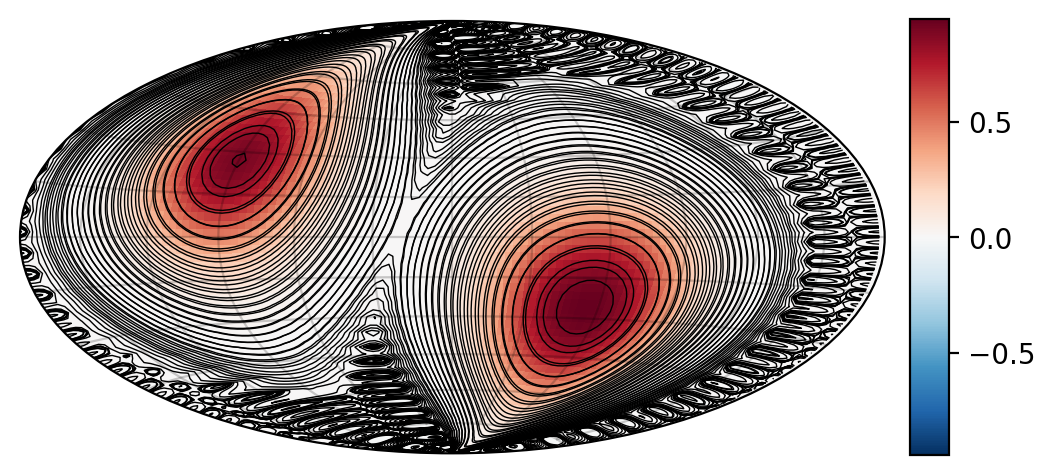

In [3]:
f1 = island_mask(N, center=[0.0,2.0,-1.0], radius=0.5)
f2 = island_mask(N, center=[-0.7,-1.0,0.55], radius=0.5, p=3)


f = scipy.ndimage.gaussian_filter(np.logical_or(f1, f2).astype(np.float64), 5.0)
F = qf.shr2mat(qf.fun2shr(f))
plot_eigenvalues(F)


### Restrict eigenvalues of F to F_c

Retained K = 2 coastline eigenvalues out of N = 64


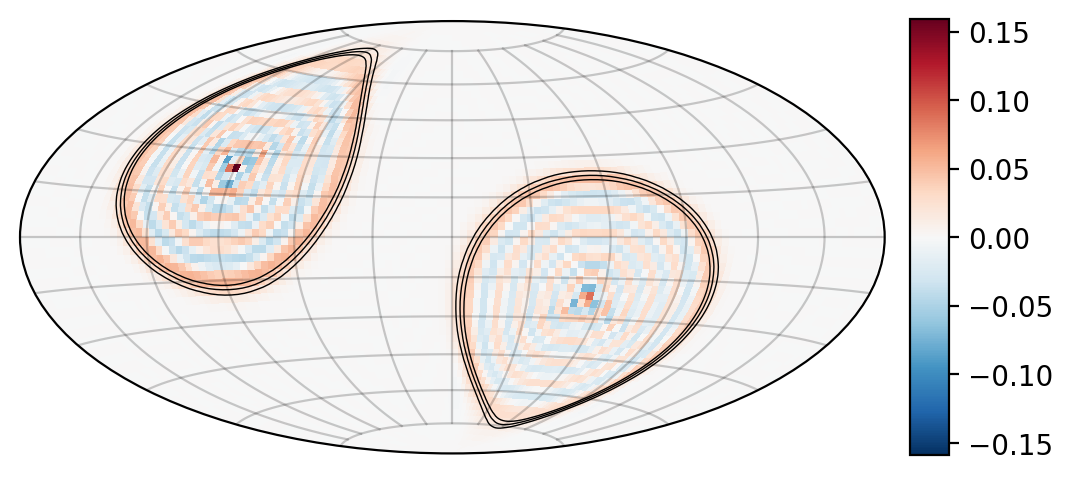

In [4]:
# Coastline parameters
level_set_center = 0.1  # target eigenvalue (imaginary part)
level_set_epsilon =0.02 # half-width: smaller = fewer coastline eigenvalues = sparser constraints


F_c, K = truncate_to_level_set(F, level_set_center, level_set_epsilon,linear=False)
def plotF(W):
    return qf.plot(W, contour_data=F, contours=[level_set_center -0.02,level_set_center,level_set_center +0.02],colorbar=True)
print(f"Retained K = {K} coastline eigenvalues out of N = {N}")

plotF(F_c)

## Generate random vorticity and plot it

gamma ratio is 0.0


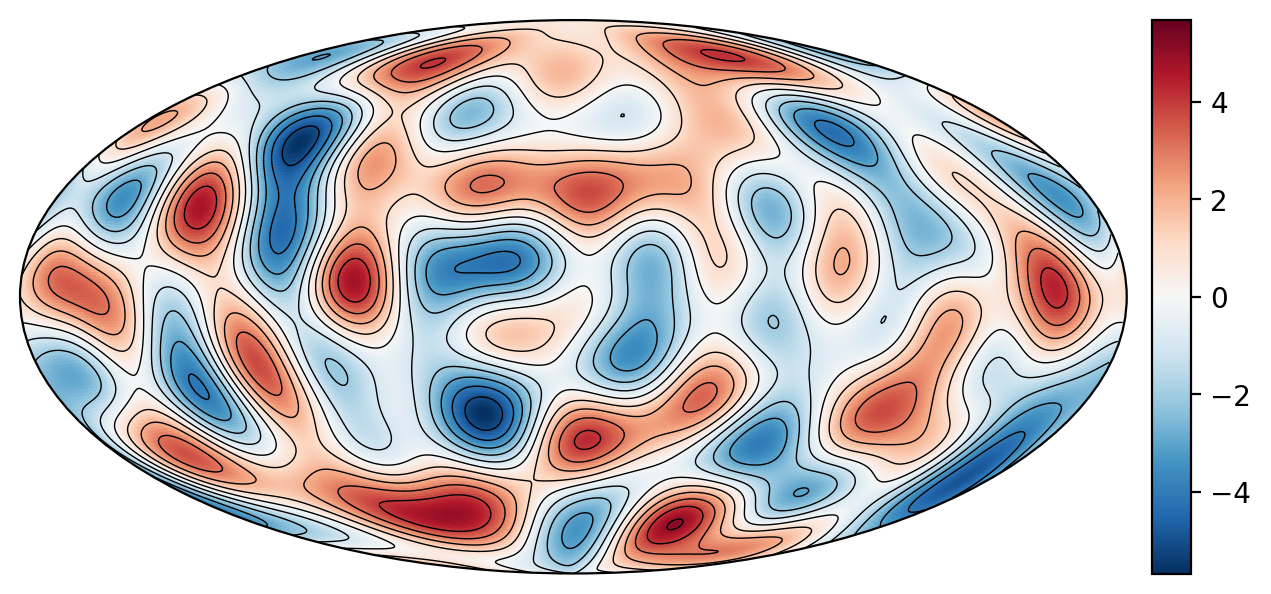

In [9]:
import matplotlib.colors as colors

omega0 = 2*qf.analysis.random_shr(lmax=10, s=0.0, gamma=0., seed=42)
els, ms = qf.ind2elm(np.arange(omega0.shape[0]))
im = qf.plot(omega0, N=256, colorbar=True, grid=False, contours=10)
print("gamma ratio is {}".format(qf.analysis.gamma_ratio(omega0)))
# plt.savefig('initial_vorticity.png', transparent=True, dpi=300)
plt.show()
W0 = qf.shr2mat(omega0, N=N)  # Convert SH coefficients to matrix

## Make the initial vorticity be zero on the islands


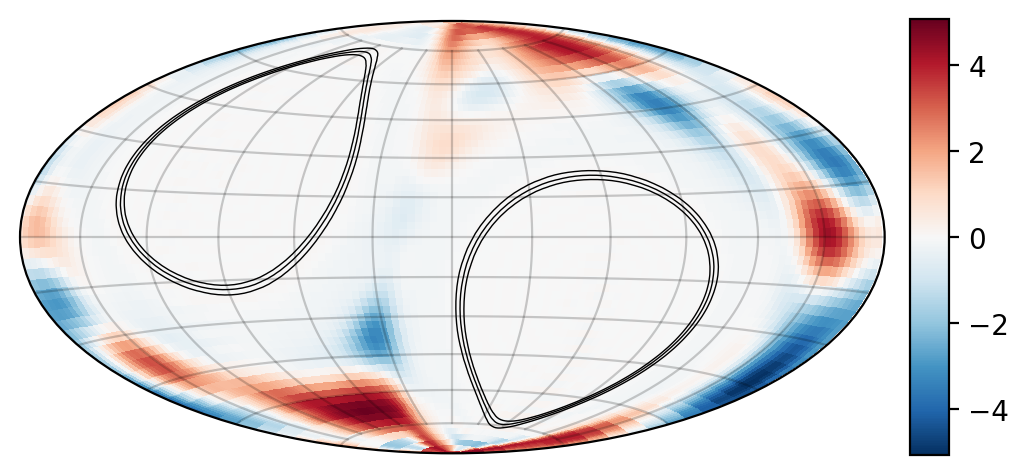

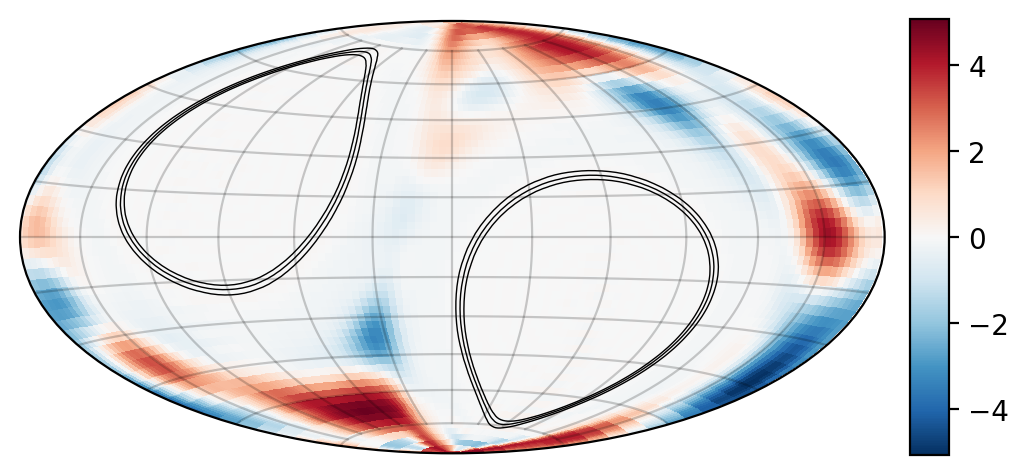

In [10]:
W0_proj = project_soft(W0,F,level_set_center,level_set_epsilon + 0.05,epsilon=0.0003)
plotF(W0_proj)
np.linalg.trace(W0_proj)
W0 = W0_proj
plotF(W0)


## Simulation of Euler's equations on the sphere

In vorticity formulation, Euler's equations are
$$\dot\omega = \{\psi,\omega\} $$
where $\omega$ is the vorticity function and $\psi$ is the stream function (related to $\omega$ via Poisson's equation). The quantized Euler equations are similar
$$\dot W = \frac{1}{\hbar}[P,W] $$
but here the vorticity function is replaced by the vorticity matrix $W \in \mathfrak{su}(N)$ and a corresponding stream matrix $P\in\mathfrak{su}(N)$.


## Externally defined functions

This steps is *very* important for cluster simulations: any code needed for the simulation that is not already part of `quflow`, must be specified here. This also includes variables that are needed at runtime.

In [11]:
# For example, define logger functions
# (exactly these loggers are also defined in `qf.physics.energy_euler` and `qf.physics.enstrophy`)
def energy(W):
    P = qf.solve_poisson(W)
    return -qf.geometry.inner_L2(W, P)

def enstrophy(W):
    return qf.geometry.inner_L2(W, W)

# For example, define a new Poisson solver here:
def solve_poisson_special(W):
    raise NotImplementedError()


# It is a good practice to save this code as
# a string and it to the QuSimulation object.
# Then the code can easily be moved to a cluster.
prerun_code += In[len(In)-1]


## Define the solver dependent on F_c
We do the whole construction of F_c again in one cell. The code in the cell will be added to the runfile.

In [12]:
prerun_code +=f"""
from quflow.constraints import *

N = {N}

constraint_method = "{constraint_method}"
solver_method="{solver_method}"

f1 = island_mask(N, center=[0.0,2.0,-1.0], radius=0.5)
f2 = island_mask(N, center=[-0.7,-1.0,0.55], radius=0.5, p=3)

f = scipy.ndimage.gaussian_filter(np.logical_or(f1, f2).astype(np.float64), 5.0)
F = qf.shr2mat(qf.fun2shr(f))

level_set_center = {level_set_center}  # target eigenvalue (imaginary part)
level_set_epsilon ={level_set_epsilon} # half-width: smaller = fewer coastline eigenvalues = sparser constraints


F_c, K = truncate_to_level_set(F, level_set_center, level_set_epsilon,linear=False)

solver = qf.constraints.CoastlinePoisson(F_c, N, method=constraint_method, solver=solver_method)
"""

## Make the simulation object

In [13]:
# Simulation
simtime = 2
inner_time = 0.2
dt = 0.1 * qf.hbar(N)

# Callback data object
mysim = qf.QuSimulation(filename, overwrite=True, state=W0, 
                        loggers={'energy':qf.physics.energy_euler, 'enstrophy':qf.physics.enstrophy})

# Set parameters for `solve` function. This is VERY convenient when moving a 
# simulation from your computer to the cluster.
mysim['dt'] = dt
mysim['simtime'] = simtime
mysim['inner_time'] = inner_time
mysim['prerun'] = prerun_code
mysim['integrator'] = qf.isomp



## Create Python script for running the simulation

Run the cell below to generate a Python script for running the simulation. If you like, you can edit it after.

In [14]:
qf.create_runfile(mysim, runfilename="mysim_runfile.py")

## Create shell script

This script is specific for Vera, but can easily be modified for other systems based on Slurm. It is important that you specify the right project number under parameter `#SBATCH -A`.

In [15]:
%%writefile run_vera.sh
#!/bin/env bash
#SBATCH -A C3SE2026-1-16 -p vera # find your project with the "projinfo" command
#SBATCH -t 7-00:00:00 # maximum simulation time is 7 days
#SBATCH -J quflow-sim # name of job
#SBATCH -n 1 # number of tasks to run
#SBATCH -c 4 # number of cores per task
#SBATCH -N 1 # use maximum 1 node
#SBATCH -C ZEN4|ICELAKE # Use ZEN4 or ICELAKE or ZEN4|ICELAKE

# Run script for starting simulations on Vera

basedir=$(dirname "$0")
if command -v module &> /dev/null
then
    # if [[ $SLURM_NTASKS =~ ^[0-9]+$ ]]; then
    #     export OMP_NUM_THREADS=$((SLURM_NTASKS*SLURM_CPUS_PER_TASK))
    # fi
    echo "Max number of threads: $OMP_NUM_THREADS"

    echo "Loading modules ..."

    # Current 
    module load FlexiBLAS/3.4.5-GCC-14.3.0
    module load SciPy-bundle/2025.07-gfbf-2025b
    module load FFmpeg/7.1.2-GCCcore-14.3.0
    module load FFTW/3.3.10-GCC-14.3.0
    module load tqdm/4.67.1-GCCcore-14.3.0
    module load matplotlib/3.10.5-gfbf-2025b
    module load virtualenv/20.32.0-GCCcore-14.3.0
    module load numba/0.62.0-foss-2025b
    module load h5py/3.14.0-foss-2025b

    if [[ `lscpu` == *"AuthenticAMD"* ]]; then 
        echo "AMD hardware found"
        export FLEXIBLAS=AOCL_MT
    else
        echo "Assuming Intel hardware"
        module load imkl/2025.2.0
        export FLEXIBLAS=IMKL
    fi
    echo "...done loading module"

    if [ -d ${HOME}/quflow-addons ]; then 
        echo "Environment ~/quflow-addons exists, activating it ..."
        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate
        echo "...done"
    else
        # Create virtualenv. You can change "quflow-addons-amd" to some other name
        # if you need to keep several environments.
        echo "Creating virtual environment ~/quflow-addons ..." 
        virtualenv --system-site-packages ${HOME}/quflow-addons
        echo "...done"

        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate

        # Install quflow as an editable module (located in the home folder)
        if [ -d ${HOME}/quflow ]; then
            echo "Local quflow directory ~/quflow exists"

            # Install quflow to the virtualenv
            echo "Pip-installing editable quflow into ~/quflow-addons ..."
            pip install -e ${HOME}/quflow
            echo "...done"

        else
            # Install non-editable (regular) quflow
            echo "Pip-installing non-editable quflow into ~/quflow-addons ..."
            pip install https://github.com/andrmykl/quflow/archive/master.zip
            echo "...done"
        fi
    fi
fi

echo "Running command: python -u $@"
start=`date +%s`
python -u "$@"
end=`date +%s`
runtime=$((end-start))
echo "...finished in $runtime seconds"


Overwriting run_vera.sh


## Run a short simulation

This is just to try things out (so that the stepsize is reasonable). A good aim is to have about 4 iterations per time-step.

  0%|          | 0/640 [00:00<?, ? steps/s]

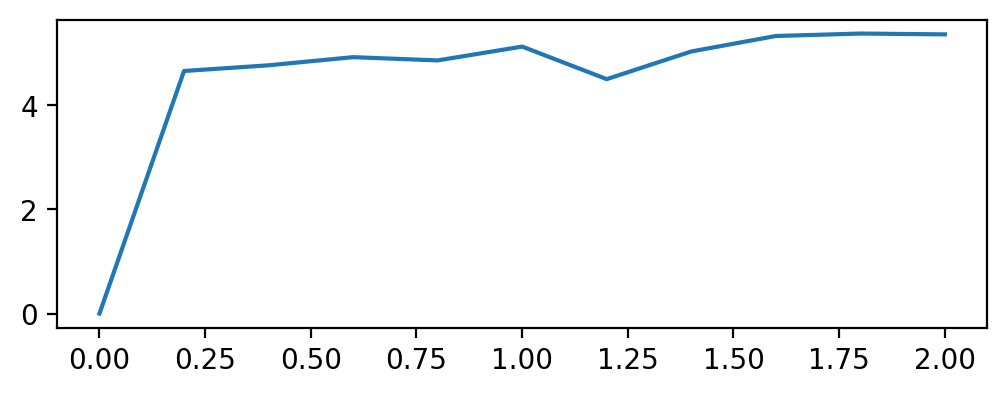

In [ ]:
# Run simulation directly from QuSimulation object
qf.solve(mysim,hamiltonian=solver.solve)

# Plot average number of iterations over time.
# This is a good check that everything went well 
# (you should select the time-step so that you 
# never hit `maxit` which defaults to 10).
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    plt.plot(mysim['time'], mysim['iterations'])

In [ ]:
from tqdm import tqdm
from IPython.display import Video

animfile = filename.replace(".hdf5", ".mp4")

with qf.QuSimulation(filename) as mysim, qf.Animation(
    animfile,
    N=256,
    contour_data=F,
    contours=[level_set_center],
    grid=False,
    colorbar=True
) as anim:
        for k in tqdm(range(0, len(mysim['time']))):
            t = mysim['time', k]
            data = mysim['fun', k]
            anim.update(data, time=t)

        


100%|██████████| 11/11 [00:00<00:00, 17.09it/s]


## Copy files to the cluster

Now copy the `quflow` simulation file `mysim_N_512.hdf5`, the Python script file `mysim_runfile.py`, and the cluster-specific shell command file `run_vera.sh` to Vera, for example via `scp`. More information on how to copy files to Vera can be found at [this link](https://www.c3se.chalmers.se/documentation/file_transfer/).

## Start the simulation on Vera

Now login via `ssh` to Vera. Change to the directory where you uploaded your files. Now, to schedule a `quflow` run on Vera, execute the following command:
```
sbatch -c 8 run_vera.sh mysim_runfile.py --simtime 100 -f mysim_N_512.hdf5
```
Here, the option `--simtime` specifies the simulation time for the run (added to the last output time). One can also use the option `--endtime` which sets the absolute end simulation time. The option `-c` specifies the number of cores to use. A good rule for the number of cores is as follows

| N | cores |
|---|-------|
|256 | 4 |
|512 | 8 |
|1024 | 16 |
|2048 | 32 |